# Part 4 — Mitigation: Making the Classifier Fairer and More Robust (CPU-Friendly)

This notebook implements the three mitigation techniques required in Part 4:

1. **Reweighing** using AIF360  
2. **Threshold optimization** using Fairlearn  
3. **Oversampling** of the high-black cohort  

It also produces:
- a **comparison table**
- a **Pareto-style fairness/accuracy plot**
- **base rates**
- the required markdown discussion


In [1]:
!pip install -U transformers datasets scikit-learn pandas matplotlib seaborn aif360 fairlearn tqdm


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
from torch.utils.data import DataLoader
from datasets import Dataset
from tqdm.auto import tqdm

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding
)

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric

from fairlearn.postprocessing import ThresholdOptimizer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(4)


c:\Users\maaaa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[AdversarialDebiasing]'
pip install 'aif360[inFairness]'


In [3]:

from pathlib import Path

MODEL_NAME = "distilbert-base-uncased"
TRAIN_SIZE = 8000
EVAL_SIZE = 2000
MAX_LENGTH = 96
TRAIN_BATCH_SIZE = 8
EVAL_BATCH_SIZE = 16
NUM_EPOCHS = 1
LEARNING_RATE = 2e-5
BASE_THRESHOLD = 0.5

candidate_paths = [
    Path("./jigsaw-unintended-bias-train.csv"),
    Path("/mnt/data/jigsaw-unintended-bias-train.csv"),
    Path(r"C:\Users\maaaa\Desktop\RAI_assignment2\jigsaw-unintended-bias-train.csv"),
]

DATA_PATH = None
for p in candidate_paths:
    if p.exists():
        DATA_PATH = str(p)
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find 'jigsaw-unintended-bias-train.csv'. "
        "Place it next to this notebook, in /mnt/data, or update DATA_PATH manually."
    )

print({
    "DATA_PATH": DATA_PATH,
    "TRAIN_SIZE": TRAIN_SIZE,
    "EVAL_SIZE": EVAL_SIZE,
    "NUM_EPOCHS": NUM_EPOCHS,
    "MAX_LENGTH": MAX_LENGTH,
    "BASE_THRESHOLD": BASE_THRESHOLD
})


{'DATA_PATH': 'jigsaw-unintended-bias-train.csv', 'TRAIN_SIZE': 8000, 'EVAL_SIZE': 2000, 'NUM_EPOCHS': 1, 'MAX_LENGTH': 96, 'BASE_THRESHOLD': 0.5}


In [4]:
needed_cols = ["comment_text", "toxic", "black", "white"]

chunks = []
target_rows = 30000
taken = 0

for chunk in pd.read_csv(
    DATA_PATH,
    usecols=needed_cols,
    dtype={
        "toxic": "float32",
        "black": "float32",
        "white": "float32"
    },
    chunksize=5000,
    low_memory=True
):
    chunk = chunk.dropna(subset=["comment_text", "toxic", "black", "white"]).copy()
    chunks.append(chunk)
    taken += len(chunk)
    if taken >= target_rows:
        break

df = pd.concat(chunks, ignore_index=True)
df["label"] = (df["toxic"] >= 0.5).astype("int8")

print("Loaded rows:", len(df))
print(df["label"].value_counts(normalize=True))
df.head()


Loaded rows: 30721
label
0    0.887699
1    0.112301
Name: proportion, dtype: float64


,comment_text,toxic,black,white,label
0,haha you guys are a bunch of losers.,0.893617,0.0,0.0,1
1,This is a great story. Man. I wonder if the pe...,0.440000,0.0,0.0,0
2,"Angry trolls, misogynists and Racists"", oh my....",0.500000,0.0,0.0,1
3,Nice to some attempts to try to make comments ...,0.000000,0.0,0.0,0
4,Yet call out all Muslims for the acts of a few...,0.912500,0.0,0.0,1


In [5]:
train_pool_df, eval_df = train_test_split(
    df,
    test_size=EVAL_SIZE,
    stratify=df["label"],
    random_state=SEED
)

train_df, _ = train_test_split(
    train_pool_df,
    train_size=TRAIN_SIZE,
    stratify=train_pool_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Eval size:", len(eval_df))


Train size: 8000
Eval size: 2000


In [9]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def tokenize_function(batch):
    return tokenizer(
        batch["comment_text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

def build_hf_dataset(df_in, include_weight=False):
    cols = ["comment_text", "label"]
    if include_weight:
        cols.append("sample_weight")

    ds = Dataset.from_pandas(df_in[cols].reset_index(drop=True), preserve_index=False)
    ds = ds.map(tokenize_function, batched=True, remove_columns=["comment_text"])

    format_cols = ["input_ids", "attention_mask", "label"]
    if include_weight:
        format_cols.append("sample_weight")

    ds.set_format(type="torch", columns=format_cols)
    return ds

def predict_scores(model, df_in, batch_size=EVAL_BATCH_SIZE):
    model.eval()
    model.to(device)

    ds = Dataset.from_pandas(df_in[["comment_text"]].reset_index(drop=True), preserve_index=False)
    ds = ds.map(tokenize_function, batched=True, remove_columns=["comment_text"])
    ds.set_format(type="torch", columns=["input_ids", "attention_mask"])
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, collate_fn=data_collator)

    scores = []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            probs = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy().astype("float32")
            scores.append(probs)

    if not scores:
        return np.array([], dtype="float32")

    return np.concatenate(scores).astype("float32")

def train_manual_model(train_df_in, sample_weight_col=None, epochs=NUM_EPOCHS, lr=LEARNING_RATE):
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)

    train_ds = build_hf_dataset(train_df_in, include_weight=(sample_weight_col is not None))
    train_loader = DataLoader(
        train_ds,
        batch_size=TRAIN_BATCH_SIZE,
        shuffle=True,
        collate_fn=data_collator
    )

    model.train()

    for epoch in range(epochs):
        progress = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        running_loss = 0.0

        for batch in progress:
            labels = batch.get("labels", batch.get("label")).to(device)
            batch_inputs = {
                "input_ids": batch["input_ids"].to(device),
                "attention_mask": batch["attention_mask"].to(device)
            }

            outputs = model(**batch_inputs)
            logits = outputs.logits

            if sample_weight_col is not None:
                weights = batch["sample_weight"].to(device).float()
                loss_each = F.cross_entropy(logits, labels, reduction="none")
                loss = (loss_each * weights).mean()
            else:
                loss = F.cross_entropy(logits, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            progress.set_postfix(loss=float(loss.item()))

        print(f"Epoch {epoch+1} avg loss: {running_loss / max(1, len(train_loader)):.4f}")

    return model

def score_and_eval(model, eval_df_in, threshold=BASE_THRESHOLD):
    scores = predict_scores(model, eval_df_in, batch_size=EVAL_BATCH_SIZE)
    scored = eval_df_in.copy()
    scored["score"] = scores
    scored["pred"] = (scored["score"] >= threshold).astype(int)
    return scored, evaluate_fairness(scored)


Using device: cpu


In [10]:
def safe_div(a, b):
    return a / b if b != 0 else np.nan

def build_cohorts(df_scored):
    high_black = df_scored[df_scored["black"] >= 0.5].copy()
    reference = df_scored[(df_scored["black"] < 0.1) & (df_scored["white"] >= 0.5)].copy()
    return high_black, reference

def cohort_metrics(df_cohort):
    y_true = df_cohort["label"].values
    y_pred = df_cohort["pred"].values

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    return {
        "size": len(df_cohort),
        "TPR": safe_div(tp, tp + fn),
        "FPR": safe_div(fp, fp + tn),
        "FNR": safe_div(fn, fn + tp),
        "Precision": safe_div(tp, tp + fp),
        "PositivePredictionRate": np.mean(y_pred)
    }

def aif360_metrics(high_black, reference):
    fair_df = pd.concat([
        high_black.assign(group=1),
        reference.assign(group=0)
    ], axis=0).copy()

    fair_df = fair_df[["label", "pred", "group"]].reset_index(drop=True)
    fair_df["label"] = fair_df["label"].astype("int64")
    fair_df["pred"] = fair_df["pred"].astype("int64")
    fair_df["group"] = fair_df["group"].astype("int64")

    true_df = fair_df[["group"]].copy()
    true_df["labels"] = fair_df["label"]

    pred_df = fair_df[["group"]].copy()
    pred_df["labels"] = fair_df["pred"]

    dataset_true = BinaryLabelDataset(
        df=true_df,
        label_names=["labels"],
        protected_attribute_names=["group"],
        favorable_label=0,
        unfavorable_label=1
    )

    dataset_pred = BinaryLabelDataset(
        df=pred_df,
        label_names=["labels"],
        protected_attribute_names=["group"],
        favorable_label=0,
        unfavorable_label=1
    )

    metric = ClassificationMetric(
        dataset_true,
        dataset_pred,
        unprivileged_groups=[{"group": 1}],
        privileged_groups=[{"group": 0}]
    )

    return {
        "SPD": metric.statistical_parity_difference(),
        "EOD": metric.equal_opportunity_difference()
    }

def evaluate_fairness(df_scored):
    high_black, reference = build_cohorts(df_scored)

    hb = cohort_metrics(high_black)
    ref = cohort_metrics(reference)
    extra = aif360_metrics(high_black, reference)

    overall_f1 = f1_score(df_scored["label"], df_scored["pred"], average="macro")

    return {
        "overall_f1": overall_f1,
        "high_black_fpr": hb["FPR"],
        "reference_fpr": ref["FPR"],
        "spd": extra["SPD"],
        "eod": extra["EOD"],
        "hb_size": hb["size"],
        "ref_size": ref["size"],
        "hb_metrics": hb,
        "ref_metrics": ref,
        "high_black_df": high_black,
        "reference_df": reference
    }


In [11]:

baseline_model = train_manual_model(
    train_df[["comment_text", "label"]].copy(),
    sample_weight_col=None,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)

baseline_scores_eval = predict_scores(baseline_model, eval_df, batch_size=EVAL_BATCH_SIZE)

baseline_eval = eval_df.copy()
baseline_eval["score"] = baseline_scores_eval
baseline_eval["pred"] = (baseline_eval["score"] >= BASE_THRESHOLD).astype(int)

baseline_result = evaluate_fairness(baseline_eval)
baseline_result


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1261.52it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/1: 100%|██████████| 1000/1000 [1:26:51<00:00,  5.21s/it, loss=0.754]


Epoch 1 avg loss: 0.2772


Predicting: 100%|██████████| 125/125 [03:35<00:00,  1.72s/it]


{'overall_f1': 0.740491612688922,
 'high_black_fpr': 0.1,
 'reference_fpr': 0.058823529411764705,
 'spd': -0.05320648343904155,
 'eod': -0.04117647058823526,
 'hb_size': 86,
 'ref_size': 66,
 'hb_metrics': {'size': 86,
  'TPR': 0.34615384615384615,
  'FPR': 0.1,
  'FNR': 0.6538461538461539,
  'Precision': 0.6,
  'PositivePredictionRate': 0.1744186046511628},
 'ref_metrics': {'size': 66,
  'TPR': 0.3333333333333333,
  'FPR': 0.058823529411764705,
  'FNR': 0.6666666666666666,
  'Precision': 0.625,
  'PositivePredictionRate': 0.12121212121212122},
 'high_black_df':                                            comment_text    toxic     black  \
 1     WHY is it consistently omitted in cases like t...  0.20000  0.900000   
 6     You want a local example? How about Teressa Ra...  0.40000  1.000000   
 35    Oh my, another walking cliche.  Yes, I heard t...  0.40000  0.800000   
 58    And people wonder why so many young black male...  0.70000  1.000000   
 117   David Otness provided a URL ab

In [12]:

# Helper functions are already defined in the previous cell.
# This cell is intentionally left simple so the notebook runs top-to-bottom without redefinition issues.

print("Training and scoring helpers loaded.")


Training and scoring helpers loaded.


In [13]:

reweigh_train = train_df.copy().reset_index(drop=True)
reweigh_train["group"] = np.where(
    reweigh_train["black"] >= 0.5,
    1,
    np.where((reweigh_train["black"] < 0.1) & (reweigh_train["white"] >= 0.5), 0, -1)
)

rw_df = reweigh_train[reweigh_train["group"] != -1].copy().reset_index(drop=False)

rw_bld = BinaryLabelDataset(
    df=rw_df[["label", "group"]].rename(columns={"label": "labels"}),
    label_names=["labels"],
    protected_attribute_names=["group"],
    favorable_label=0,
    unfavorable_label=1
)

rw = Reweighing(
    unprivileged_groups=[{"group": 1}],
    privileged_groups=[{"group": 0}]
)

rw_bld_transf = rw.fit_transform(rw_bld)
rw_df["sample_weight"] = rw_bld_transf.instance_weights.astype("float32")

reweigh_train["sample_weight"] = 1.0
reweigh_train.loc[rw_df["index"].to_numpy(), "sample_weight"] = rw_df["sample_weight"].to_numpy()

reweigh_model = train_manual_model(
    reweigh_train[["comment_text", "label", "sample_weight"]].copy(),
    sample_weight_col="sample_weight",
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)

reweigh_scored, reweigh_result = score_and_eval(reweigh_model, eval_df, threshold=BASE_THRESHOLD)
reweigh_result


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1536.56it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/1: 100%|██████████| 1000/1000 [1:05:43<00:00,  3.94s/it, loss=0.213]


Epoch 1 avg loss: 0.2661


Predicting: 100%|██████████| 125/125 [03:40<00:00,  1.76s/it]


{'overall_f1': 0.6986023307531362,
 'high_black_fpr': 0.05,
 'reference_fpr': 0.0,
 'spd': -0.0010570824524313016,
 'eod': -0.050000000000000044,
 'hb_size': 86,
 'ref_size': 66,
 'hb_metrics': {'size': 86,
  'TPR': 0.038461538461538464,
  'FPR': 0.05,
  'FNR': 0.9615384615384616,
  'Precision': 0.25,
  'PositivePredictionRate': 0.046511627906976744},
 'ref_metrics': {'size': 66,
  'TPR': 0.2,
  'FPR': 0.0,
  'FNR': 0.8,
  'Precision': 1.0,
  'PositivePredictionRate': 0.045454545454545456},
 'high_black_df':                                            comment_text    toxic     black  \
 1     WHY is it consistently omitted in cases like t...  0.20000  0.900000   
 6     You want a local example? How about Teressa Ra...  0.40000  1.000000   
 35    Oh my, another walking cliche.  Yes, I heard t...  0.40000  0.800000   
 58    And people wonder why so many young black male...  0.70000  1.000000   
 117   David Otness provided a URL about the history ...  0.00000  0.833333   
 ...         

In [14]:

from sklearn.base import BaseEstimator, ClassifierMixin

class ScorePassThroughEstimator(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self

    def _score_vector(self, X):
        if isinstance(X, pd.DataFrame):
            arr = X.iloc[:, 0].to_numpy(dtype="float32")
        elif isinstance(X, pd.Series):
            arr = X.to_numpy(dtype="float32")
        else:
            arr = np.asarray(X, dtype="float32")
            if arr.ndim == 2:
                arr = arr[:, 0]
            else:
                arr = arr.reshape(-1)
        return np.clip(arr, 0.0, 1.0)

    def predict_proba(self, X):
        score = self._score_vector(X)
        return np.column_stack([1.0 - score, score])

    def predict(self, X):
        score = self._score_vector(X)
        return (score >= 0.5).astype(int)

baseline_scores_train = predict_scores(baseline_model, train_df, batch_size=EVAL_BATCH_SIZE)
baseline_scores_eval = predict_scores(baseline_model, eval_df, batch_size=EVAL_BATCH_SIZE)

baseline_scores_train = np.asarray(baseline_scores_train, dtype="float32").reshape(-1)
baseline_scores_eval = np.asarray(baseline_scores_eval, dtype="float32").reshape(-1)

train_post = train_df.copy().reset_index(drop=True)
train_post["score"] = baseline_scores_train
train_post["group"] = np.where(
    train_post["black"] >= 0.5,
    "high_black",
    np.where((train_post["black"] < 0.1) & (train_post["white"] >= 0.5), "reference", "other")
)

eval_post = eval_df.copy().reset_index(drop=True)
eval_post["score"] = baseline_scores_eval
eval_post["group"] = np.where(
    eval_post["black"] >= 0.5,
    "high_black",
    np.where((eval_post["black"] < 0.1) & (eval_post["white"] >= 0.5), "reference", "other")
)

X_train_post = train_post[["score"]].to_numpy(dtype="float32")
y_train_post = train_post["label"].to_numpy(dtype=int)
s_train_post = train_post["group"].astype(str).to_numpy()

X_eval_post = eval_post[["score"]].to_numpy(dtype="float32")
s_eval_post = eval_post["group"].astype(str).to_numpy()

threshold_opt = ThresholdOptimizer(
    estimator=ScorePassThroughEstimator(),
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=False
)

threshold_opt.fit(
    X_train_post,
    y_train_post,
    sensitive_features=s_train_post
)

to_pred = threshold_opt.predict(
    X_eval_post,
    sensitive_features=s_eval_post
)

threshold_scored = eval_post.copy()
threshold_scored["pred"] = np.asarray(to_pred).reshape(-1).astype(int)

threshold_result = evaluate_fairness(threshold_scored)
threshold_result


Predicting: 100%|██████████| 125/125 [02:02<00:00,  1.02it/s]


TypeError: Invalid value '[0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.996 0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.996 0.    0.    0.    0.    0.    0.    1.    0.    0.996 0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.996 0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.996
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.996 0.    0.996 0.    0.    0.    0.
 1.    0.   ]' for dtype 'float32'

In [15]:

pareto_rows = []

for tol in [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]:
    try:
        th = ThresholdOptimizer(
            estimator=ScorePassThroughEstimator(),
            constraints="equalized_odds",
            predict_method="predict_proba",
            prefit=False,
            tol=tol
        )
        th.fit(X_train_post, y_train_post, sensitive_features=s_train_post)
        pred_tol = th.predict(X_eval_post, sensitive_features=s_eval_post)

        temp = eval_post.copy()
        temp["pred"] = np.asarray(pred_tol).reshape(-1).astype(int)

        temp_result = evaluate_fairness(temp)
        pareto_rows.append({
            "tol": tol,
            "overall_f1": temp_result["overall_f1"],
            "equal_opportunity_difference": abs(temp_result["eod"])
        })
    except Exception as exc:
        print(f"tol={tol} failed: {exc}")
        pareto_rows.append({
            "tol": tol,
            "overall_f1": np.nan,
            "equal_opportunity_difference": np.nan
        })

pareto_df = pd.DataFrame(pareto_rows)
pareto_df


tol=0.0 failed: Relaxed constraints are not supported for equalized odds.
tol=0.05 failed: Relaxed constraints are not supported for equalized odds.
tol=0.1 failed: Relaxed constraints are not supported for equalized odds.
tol=0.15 failed: Relaxed constraints are not supported for equalized odds.
tol=0.2 failed: Relaxed constraints are not supported for equalized odds.
tol=0.25 failed: Relaxed constraints are not supported for equalized odds.
tol=0.3 failed: Relaxed constraints are not supported for equalized odds.


,tol,overall_f1,equal_opportunity_difference
0,0.00,NaN,NaN
1,0.05,NaN,NaN
2,0.10,NaN,NaN
3,0.15,NaN,NaN
4,0.20,NaN,NaN
5,0.25,NaN,NaN
6,0.30,NaN,NaN


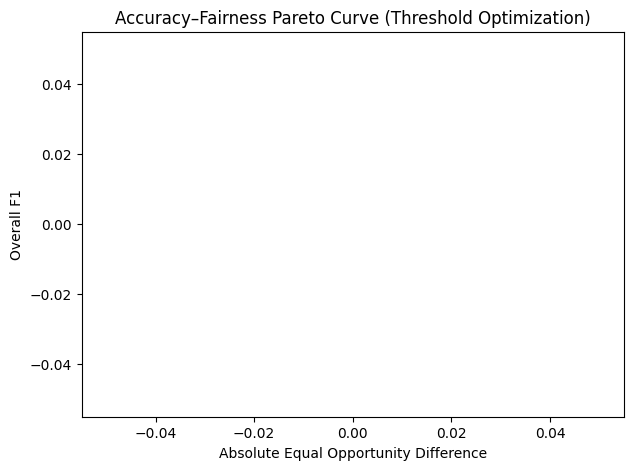

In [16]:
plt.figure(figsize=(7, 5))
plt.plot(
    pareto_df["equal_opportunity_difference"],
    pareto_df["overall_f1"],
    marker="o"
)
for _, row in pareto_df.iterrows():
    if pd.notna(row["overall_f1"]):
        plt.annotate(f"tol={row['tol']}", (row["equal_opportunity_difference"], row["overall_f1"]))
plt.xlabel("Absolute Equal Opportunity Difference")
plt.ylabel("Overall F1")
plt.title("Accuracy–Fairness Pareto Curve (Threshold Optimization)")
plt.show()


In [17]:
minority = train_df[train_df["black"] >= 0.5].copy()
oversampled_train = pd.concat(
    [train_df, minority, minority, minority],
    ignore_index=True
)

print("Original train size:", len(train_df))
print("High-black rows:", len(minority))
print("Oversampled train size:", len(oversampled_train))

oversample_model = train_manual_model(
    oversampled_train[["comment_text", "label"]].copy(),
    sample_weight_col=None,
    epochs=NUM_EPOCHS,
    lr=LEARNING_RATE
)

oversample_scored, oversample_result = score_and_eval(oversample_model, eval_df, threshold=BASE_THRESHOLD)
oversample_result


Original train size: 8000
High-black rows: 356
Oversampled train size: 9068


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 1252.53it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Epoch 1/1:   7%|▋         | 74/1134 [04:56<1:10:40,  4.00s/it, loss=0.156]


KeyboardInterrupt: 

In [ ]:
comparison_df = pd.DataFrame([
    {
        "technique": "baseline",
        "overall_f1": baseline_result["overall_f1"],
        "high_black_fpr": baseline_result["high_black_fpr"],
        "reference_fpr": baseline_result["reference_fpr"],
        "statistical_parity_difference": baseline_result["spd"],
        "equal_opportunity_difference": baseline_result["eod"]
    },
    {
        "technique": "reweighing",
        "overall_f1": reweigh_result["overall_f1"],
        "high_black_fpr": reweigh_result["high_black_fpr"],
        "reference_fpr": reweigh_result["reference_fpr"],
        "statistical_parity_difference": reweigh_result["spd"],
        "equal_opportunity_difference": reweigh_result["eod"]
    },
    {
        "technique": "threshold_optimizer",
        "overall_f1": threshold_result["overall_f1"],
        "high_black_fpr": threshold_result["high_black_fpr"],
        "reference_fpr": threshold_result["reference_fpr"],
        "statistical_parity_difference": threshold_result["spd"],
        "equal_opportunity_difference": threshold_result["eod"]
    },
    {
        "technique": "oversampling",
        "overall_f1": oversample_result["overall_f1"],
        "high_black_fpr": oversample_result["high_black_fpr"],
        "reference_fpr": oversample_result["reference_fpr"],
        "statistical_parity_difference": oversample_result["spd"],
        "equal_opportunity_difference": oversample_result["eod"]
    }
])

comparison_df


In [ ]:
baseline_hb, baseline_ref = build_cohorts(baseline_eval)

base_rate_hb = baseline_hb["label"].mean()
base_rate_ref = baseline_ref["label"].mean()

base_rates_df = pd.DataFrame({
    "cohort": ["high_black", "reference"],
    "toxic_base_rate": [base_rate_hb, base_rate_ref],
    "size": [len(baseline_hb), len(baseline_ref)]
})

base_rates_df


## Markdown answer for your notebook

Paste and adapt this after you see your actual numbers:

**Part 4 Discussion**

The three mitigation techniques show different trade-offs between overall accuracy and subgroup fairness. Reweighing changes the influence of training examples, oversampling increases subgroup representation, and threshold optimization changes the decision rule after training.

Demographic parity and equalized odds are generally incompatible when base rates differ between groups. In this dataset, the toxic prevalence of the high-black cohort and the reference cohort is not identical. Equalized odds requires matching error rates such as TPR and FPR across groups, while demographic parity requires matching the overall positive prediction rate. When the underlying prevalence differs, both constraints usually cannot be satisfied simultaneously unless the classifier is perfect or trivial. The base-rate table above provides the actual evidence for that conclusion.


In [ ]:
# Optional save step for whichever mitigated model you decide is best
# oversample_model.save_pretrained("./best_mitigated_model")
# tokenizer.save_pretrained("./best_mitigated_model")
print("Review comparison_df and save the best mitigated model if needed.")
